World Bank Economic Data ( Cleaning and Analysis)
Author : Aiman Ishaq
Data Source : World Bank Open Data
Indicators Used:
   GDP per capita (current USD)
   Inflation, consumer prices(annual%)
   Unemployment, total(% of total labour force)
Objective
The World Bank publishes country level economic indicators in wide format (one column per year), with mixed aggregate regions and real countries in the same file. This notebook:
1. Cleans and reshapes three indicator files into a single tidy long format Dataset
2. Filters to real countries only (removes regional aggregates like WLD, ECA)
3. Engineers Pakistan's features for downstream analysis
4. Explores Pakistan's economic trajectory VS the South Asia regional average

1. imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
plt.rcParams.update({'figure.dpi': 130,'axes.spines.top': False, 'axes.spines.right': False,'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize' : 11})


2. Load Data
World Bank CSVs have 4 metadata rows at the top (skip=4 skips them)

In [2]:
DATA_DIR = 'data/'
gdp = pd.read_csv(DATA_DIR + 'GDP.csv', skiprows=4)
inflation = pd.read_csv(DATA_DIR + 'inflation.csv', skiprows=4)
unemployment = pd.read_csv(DATA_DIR + 'unemployment.csv', skiprows=4)

In [3]:
print('GDP shape:', gdp.shape)
print('Inflation shape:', inflation.shape)
print('Unemployment shape:', unemployment.shape)

GDP shape: (266, 71)
Inflation shape: (266, 71)
Unemployment shape: (266, 71)


3. Clean : Drop junk Columns
Each World Bank file comes with unnamed trailing columns and two redundant indicator columns(Indicator Name, Indicator Code). we strip these first.

In [4]:
def drop_junk(df):
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df = df.drop(columns=['Indicator Name', 'Indicator Code'], errors='ignore')
    return df
gdp = drop_junk(gdp)
inflation = drop_junk(inflation)
unemployment = drop_junk(unemployment)
print("columns after dropping junk:", gdp.columns.tolist()[:8], '...')

columns after dropping junk: ['Country Name', 'Country Code', '1960', '1961', '1962', '1963', '1964', '1965'] ...


4. Filter: remove Regional Aggregates
World Bank files mix real countries (3 letter ISO codes like PAK,USA) with regional aggregates (WLD, ECA, SSA, etc.). we keep only real countries using two rules:
   country Code matches the 3 capital letter ISO pattern
   Explicitly exclude known aggregate codes that happen to match the pattern


In [5]:
NON_COUNTRY_CODES = ['WLD', 'LMY', 'UMC', 'LMC', 'LIC', 'HIC', 'MIC', 'EAP', 'ECA', 'LAC', 'MNA', 'SAS', 'SSA', 'NAC', 'OED', 'EMU']
def filter_countries(df):
    real_countries = df['Country Code'].str.match(r'^[A-Z]{3}$') 
    df = df[real_countries & ~df['Country Code'].isin(NON_COUNTRY_CODES)]
    return df.reset_index(drop=True)
gdp = filter_countries(gdp)
inflation = filter_countries(inflation)
unemployment = filter_countries(unemployment)
print(f"Countries remaining:{gdp.shape[0]}")

Countries remaining:250


5. Reshape: Wide to Long
World Bank data is in wide format (one column per year)
For analysis we need long format : one row per combination
pd.melt() handles this reshape. we also cast Year to integer for filtering and plotting

In [6]:
def wide_to_long(df, value_name):
    year_cols = [c for c in df.columns if re.match(r'^\d{4}$', str(c))]
    df_long = pd.melt(df, id_vars=['Country Name', 'Country Code'], value_vars=year_cols, var_name='Year', value_name=value_name)
    df_long['Year'] = df_long['Year'].astype(int)
    return df_long
gdp_long = wide_to_long(gdp, 'gdp_per_capita')
inflation_long = wide_to_long(inflation, 'inflation_pct')
unemployment_long = wide_to_long(unemployment, 'unemployment_pct')
print('Long GDP shape:', gdp_long.shape)
gdp_long.head()


Long GDP shape: (16500, 4)


,Country Name,Country Code,Year,gdp_per_capita
0,Aruba,ABW,1960,NaN
1,Africa Eastern and Southern,AFE,1960,186.089204
2,Afghanistan,AFG,1960,NaN
3,Africa Western and Central,AFW,1960,121.936832
4,Angola,AGO,1960,NaN


6. Merge into a Single Dataset
we join all three indicator on Country Code + Year.
A left join on GDP preserves all country year combinations from the GDP file ; missing values in inflation and unemployment are expected

In [7]:
df = gdp_long.merge(inflation_long[['Country Code','Year','inflation_pct']], on=[ 'Country Code', 'Year'], how='left')
df = df.merge(unemployment_long[['Country Code','Year','unemployment_pct']], on=[ 'Country Code', 'Year'], how='left')
print('Merged shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())

Merged shape: (16500, 6)

Missing values:
Country Name           0
Country Code           0
Year                   0
gdp_per_capita      2945
inflation_pct       7434
unemployment_pct    8849
dtype: int64


7. Filter to 1990 Onwards
Coverage before 1990 is sparse , many countries didn't report consistently during the cold war era. 
Filtering to 1990+ gives us a denser, more reliable dataset while still covering 30+ years of economic history including the Asia financial crisis, 2008 GFC, and COVID-19.

In [8]:
# Check coverage by year
coverage = df.groupby('Year')['gdp_per_capita'].count() 
print('Data coverage (countries reporting GDP per year):')
print(coverage.tail(10))
df = df[df['Year'] >= 1990].copy()
# Flag rows with missing values 
df_complete = df.dropna(subset=['gdp_per_capita', 'inflation_pct', 'unemployment_pct']).copy()
print(f"\nRows after 1990 filter: {len(df):,}")
print(f"Complete cases: {len(df_complete):,}")

Data coverage (countries reporting GDP per year):
Year
2016    243
2017    243
2018    243
2019    243
2020    242
2021    242
2022    241
2023    235
2024    224
2025      0
Name: gdp_per_capita, dtype: int64

Rows after 1990 filter: 9,000
Complete cases: 5,590


8. Standardise Country Names

In [9]:
name_fixes = {
    "Bahamas, The": "The Bahamas",
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Egypt, Arab Rep.": "Egypt",
    "Iran, Islamic Rep.": "Iran",
    "Korea, Rep.": "South Korea",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Lao PDR": "Laos",
    "Russian Federation": "Russia",
    "Syrian Arab Republic": "Syria",
    "Venezuela, RB": "Venezuela",
    "Yemen, Rep.": "Yemen"
}
df['Country Name'] = df['Country Name'].replace(name_fixes)
df_complete['Country Name'] = df_complete['Country Name'].replace(name_fixes)
print('Name standardisation applied')


Name standardisation applied


9. Feature Engineering
Three derived columns are added:
  . economic_stress_index
         mean of inflation % and unemployment % (only both are present)
         purpose is to composite hardship signal
  
  . gdp_category
         World Bank income thresholds(USD per capita)
         purpose is to Enable Group comparisons
  . decade
         Year floored to decade
         purpose is trend aggregation

In [10]:
# equal weight mean; both indicators are already in % units so scale is comparable.
# Rows where one indicator is missing still get a partial score (skipna=True) 
df['economic_stress_index'] = df[['inflation_pct', 'unemployment_pct']].mean(axis=1, skipna=True)
df['gdp_category'] = pd.cut(df['gdp_per_capita'],bins=[0,1_085,4_255,13_205,float('inf')],labels=['Low Income','Lower-Middle Income','Upper-Middle Income','High Income'])
df['decade'] = ((df['Year'] // 10)*10).astype(str) + 's'
print(df[['Country Name', 'Year', 'gdp_per_capita', 'economic_stress_index', 'gdp_category']].head(10))


                     Country Name  Year  gdp_per_capita  \
7500                        Aruba  1990    12187.536361   
7501  Africa Eastern and Southern  1990      822.402999   
7502                  Afghanistan  1990             NaN   
7503   Africa Western and Central  1990      593.024667   
7504                       Angola  1990      965.866840   
7505                      Albania  1990      617.230436   
7506                      Andorra  1990    19563.657472   
7507                   Arab World  1990     2875.130836   
7508         United Arab Emirates  1990    26709.993440   
7509                    Argentina  1990     4315.334031   

      economic_stress_index         gdp_category  
7500               5.836688  Upper-Middle Income  
7501              12.457914           Low Income  
7502                    NaN                  NaN  
7503               1.057361           Low Income  
7504                    NaN           Low Income  
7505                    NaN           Low In

10. Pakistan analysis
Pakistan is one of the world's most populous lower middle income economies.Here we examine:
  its GDP per capita trend vs South Asia regional average
  its worst inflation years
  its unemployment trajectory

In [11]:
south_asia_codes = ['IND','BGD','LKA','NPL','MDV','BTN', 'AFG']
# PAK excluded from south_asia_codes intentionally
# comparing Pakistan against its peers, not against itself

pakistan = df[df['Country Code'] == 'PAK'].copy()
south_asia = df[df['Country Code'].isin(south_asia_codes)]
sa_avg = south_asia.groupby('Year')['gdp_per_capita'].mean().rename('South Asia Avg')

worst_inflation = pakistan.loc[pakistan['inflation_pct'].idxmax()]
print(f"\nWorst inflation year: {int(worst_inflation['Year'])} at {worst_inflation['inflation_pct']:.1f}%")

print(f"\nPakistan vs South Asia average - last 10 years:")
comparison = pakistan.set_index('Year')['gdp_per_capita'].to_frame().join(sa_avg)
print(comparison.tail(10))



Worst inflation year: 2023 at 30.8%

Pakistan vs South Asia average - last 10 years:
      gdp_per_capita  South Asia Avg
Year                                
2016     1424.691612     3143.634259
2017     1519.234595     3380.677936
2018     1569.338146     3540.583272
2019     1390.416910     3610.010437
2020     1278.397352     2893.436378
2021     1455.319224     3439.346981
2022     1538.322813     3663.869910
2023     1360.324178     3870.722090
2024     1478.772780     4926.076640
2025             NaN             NaN


11. Visualisations
    11.1. Pakistan GDP per CApita vs South Asia Average

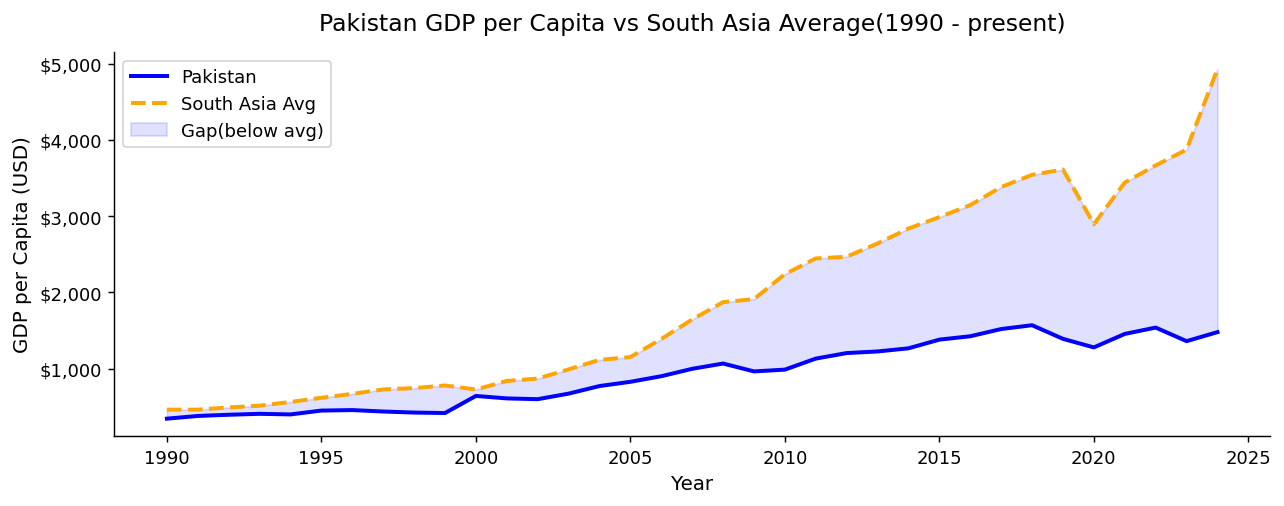

In [12]:
fig, ax = plt.subplots(figsize=(10,4))

pak_gdp = pakistan.set_index('Year')['gdp_per_capita'].dropna()
ax.plot(pak_gdp.index, pak_gdp.values, color='blue', linewidth=2.2, label='Pakistan')
ax.plot(sa_avg.index, sa_avg.values, color='orange', linewidth=2.2, linestyle='--', label='South Asia Avg')

ax.fill_between(pak_gdp.index, pak_gdp.values, sa_avg.reindex(pak_gdp.index), where=(pak_gdp.values < sa_avg.reindex(pak_gdp.index).values), color='blue', alpha=0.12, label ='Gap(below avg)')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Pakistan GDP per Capita vs South Asia Average(1990 - present)', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('GDP per Capita (USD)')
ax.legend()
plt.tight_layout()
plt.show()

11.2. Pakistan inflation History

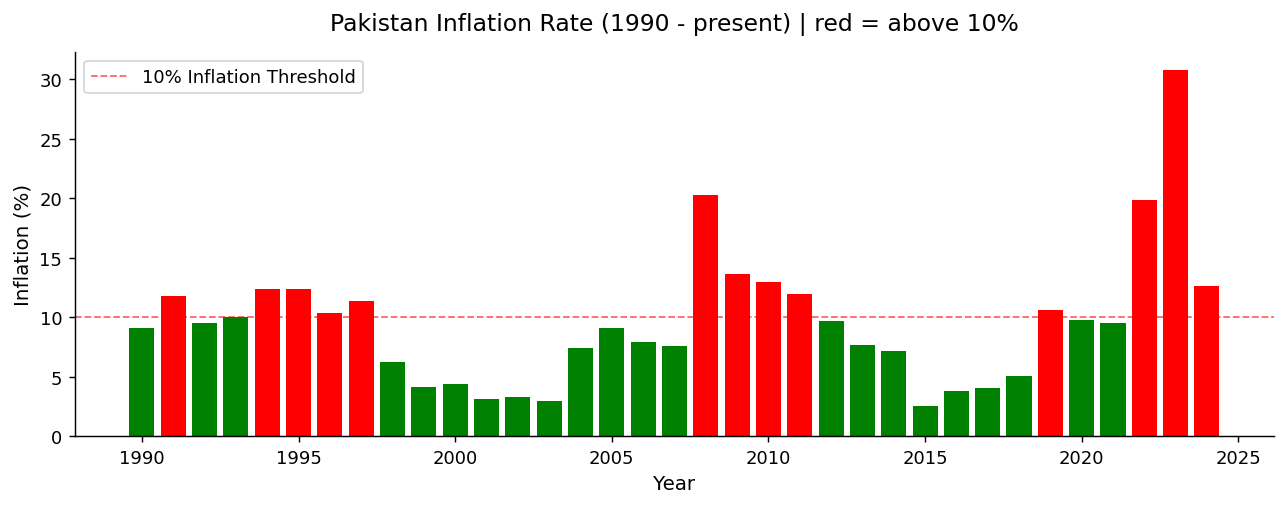

In [13]:
fig, ax = plt.subplots(figsize=(10,4))
pak_inf = pakistan[['Year', 'inflation_pct']].dropna()
colors = ['red' if v > 10 else 'green' for v in pak_inf['inflation_pct']]
ax.bar(pak_inf['Year'], pak_inf['inflation_pct'], color=colors, width=0.8)
ax.axhline(10, color='red', linestyle='--', linewidth=1, label='10% Inflation Threshold', alpha=0.6)
ax.set_title('Pakistan Inflation Rate (1990 - present) | red = above 10%', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Inflation (%)')
ax.legend()
plt.tight_layout()  
plt.show()

11.3. South Asia GDP per capita Comparison(latest year)

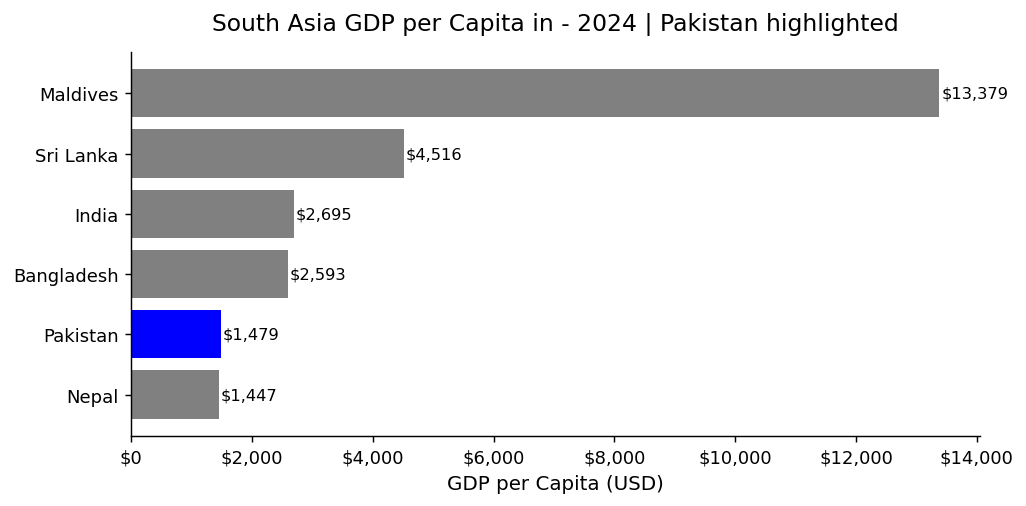

In [14]:
latest_year = south_asia.dropna(subset=['gdp_per_capita'])['Year'].max()
pak_latest = pakistan[pakistan['Year'] == latest_year][['Country Name', 'Country Code', 'gdp_per_capita']]
sa_latest = pd.concat([south_asia[south_asia['Year'] == latest_year], pak_latest]).dropna(subset=['gdp_per_capita']).sort_values('gdp_per_capita', ascending=True)
fig, ax = plt.subplots(figsize=(8,4))
bar_colors = ['blue' if code == 'PAK' else 'gray' for code in sa_latest['Country Code']]
bars = ax.barh(sa_latest['Country Name'], sa_latest['gdp_per_capita'], color=bar_colors)
for bar, val in zip(bars, sa_latest['gdp_per_capita']):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=9)
ax.set_title(f'South Asia GDP per Capita in - {latest_year} | Pakistan highlighted', pad=12)
ax.set_xlabel('GDP per Capita (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

11.4. Distribution of GDP Category by Decade

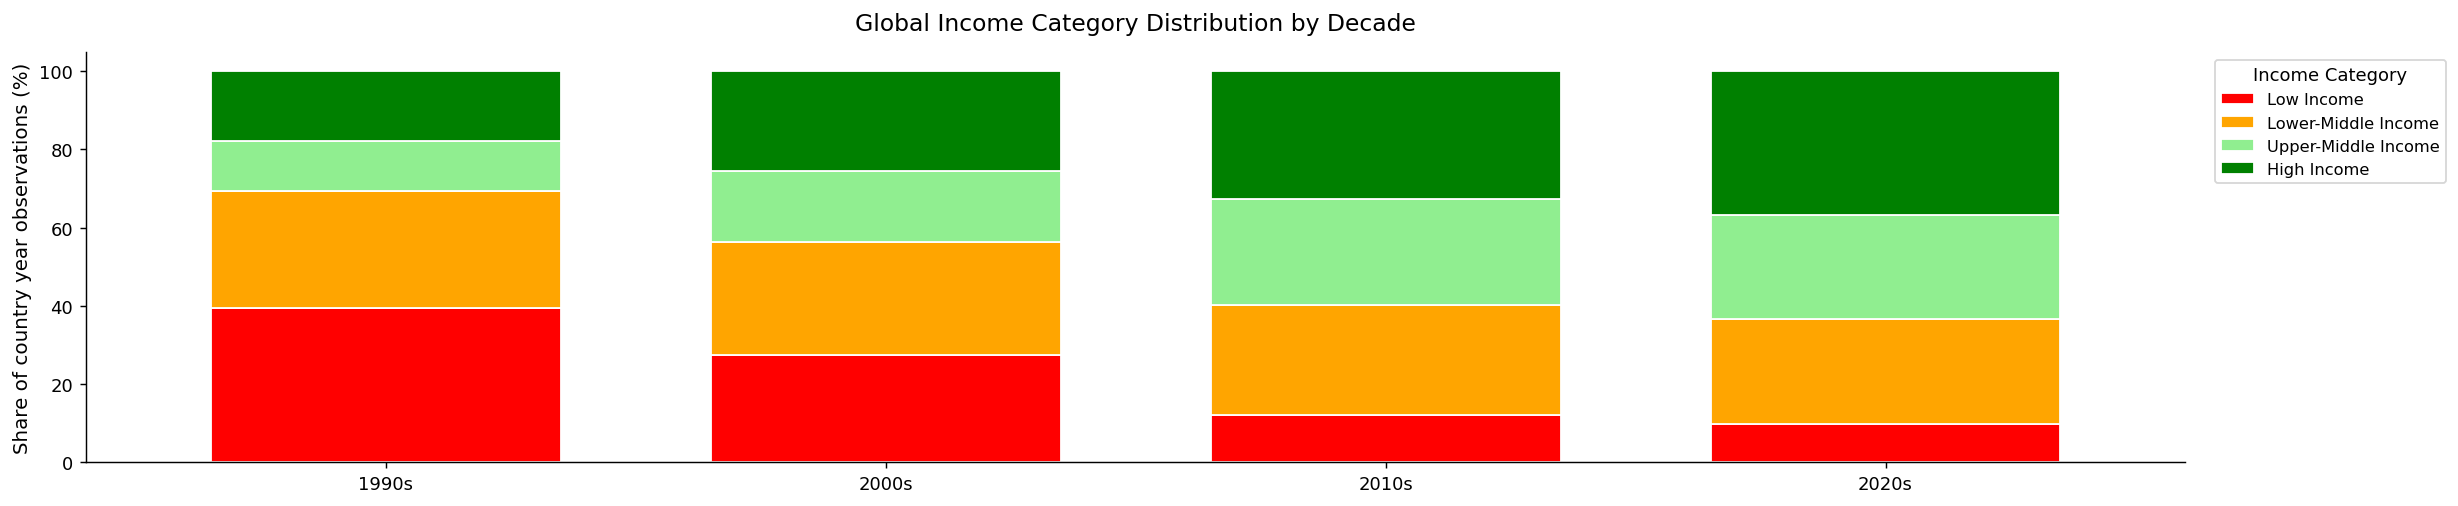

In [15]:
cat_order = ['Low Income', 'Lower-Middle Income', 'Upper-Middle Income', 'High Income']
cat_palette = {'Low Income': 'red', 'Lower-Middle Income': 'orange', 'Upper-Middle Income': 'lightgreen', 'High Income': 'green'}
decade_cat = (df.dropna(subset=['gdp_category']).groupby(['decade', 'gdp_category'], observed = True).size().unstack('gdp_category').reindex(columns=cat_order).fillna(0))
# normalise to %
decade_pct = decade_cat.div(decade_cat.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(19,4))
decade_pct.plot(kind='bar', stacked=True, ax=ax, color=cat_palette, width=0.7, edgecolor='white')
ax.set_title('Global Income Category Distribution by Decade', pad=12)
ax.set_ylabel('Share of country year observations (%)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Income Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

12. Export Clean Dataset

In [16]:
final_cols = [
    'Country Name', 'Country Code', 'Year',
    'gdp_per_capita', 'inflation_pct', 'unemployment_pct',
    'economic_stress_index', 'gdp_category', 'decade'
]
df_complete = df.dropna(subset=['gdp_per_capita', 'inflation_pct', 'unemployment_pct']).copy()

df_final = df[final_cols].sort_values(['Country Name', 'Year']).reset_index(drop=True)
df_final.to_csv('world_bank_clean.csv', index=False)
df_complete[final_cols].to_csv('world_bank_complete_cases.csv', index=False)

print(f'Full dataset: world_bank_clean.csv ({df_final.shape[0]:,} rows)')
print(f'Complete cases: world_bank_complete_cases.csv ({df_complete.shape[0]:,} rows)')
print()
print(df_final.dtypes)


Full dataset: world_bank_clean.csv (9,000 rows)
Complete cases: world_bank_complete_cases.csv (5,590 rows)

Country Name                  str
Country Code                  str
Year                        int64
gdp_per_capita            float64
inflation_pct             float64
unemployment_pct          float64
economic_stress_index     float64
gdp_category             category
decade                        str
dtype: object


13. Key Findings
    1. Pakistan's GDP growth has been volatile and structurally lagging
Pakistan has consistently trailed the South Asia average in GDP per capita since 1990. While India and Sri Lanka drove the regional average upward through sustained productivity and export-led growth, Pakistan's trajectory has been marked by boom-bust cycles. This suggests growth has been more dependent on remittances and consumption than on structural economic transformation — a distinction that matters for any long-term investment or policy risk assessment.
    2. Pakistan has experienced two distinct inflation crises
Annual inflation exceeded 10% during two concentrated periods: the early 2000s energy crisis and the 2008–2010 post-GFC spillover. These were not gradual drifts but sharp spikes, indicating that Pakistan's inflation is largely shock-driven rather than chronic demand-pull. This has direct implications for monetary policy effectiveness and currency stability modeling.
    3. Global income convergence is real but incomplete
The share of High Income and Upper-Middle Income countries has grown each decade since 1990, consistent with broad development gains across East Asia, Eastern Europe, and Latin America. However, the Low Income share has not meaningfully declined — suggesting convergence is benefiting the middle tiers disproportionately, while the poorest economies remain structurally stuck.
    4. Unemployment data is the primary reliability constraint
Coverage gaps are concentrated in the unemployment indicator, a known limitation of World Bank self-reported data. Any downstream model using this dataset — particularly the economic stress index — should treat unemployment-derived features with caution, or apply imputation with explicit assumptions rather than dropping incomplete rows silently. 